# EDA CODE


--- Data Dimensions ---
Rows: 500, Columns: 4
Duplicate Rows Found: 0

--- Statistical Summary ---


,Price,Rating,Title_Length
count,500.000000,500.000000,500.000000
mean,35.040400,2.928000,41.922000
std,14.553083,1.429301,27.953868
min,10.160000,1.000000,4.000000
25%,21.857500,2.000000,19.000000
50%,36.650000,3.000000,37.000000
75%,47.745000,4.000000,58.000000
max,59.900000,5.000000,175.000000



Correlation between Rating and Price: 0.0042


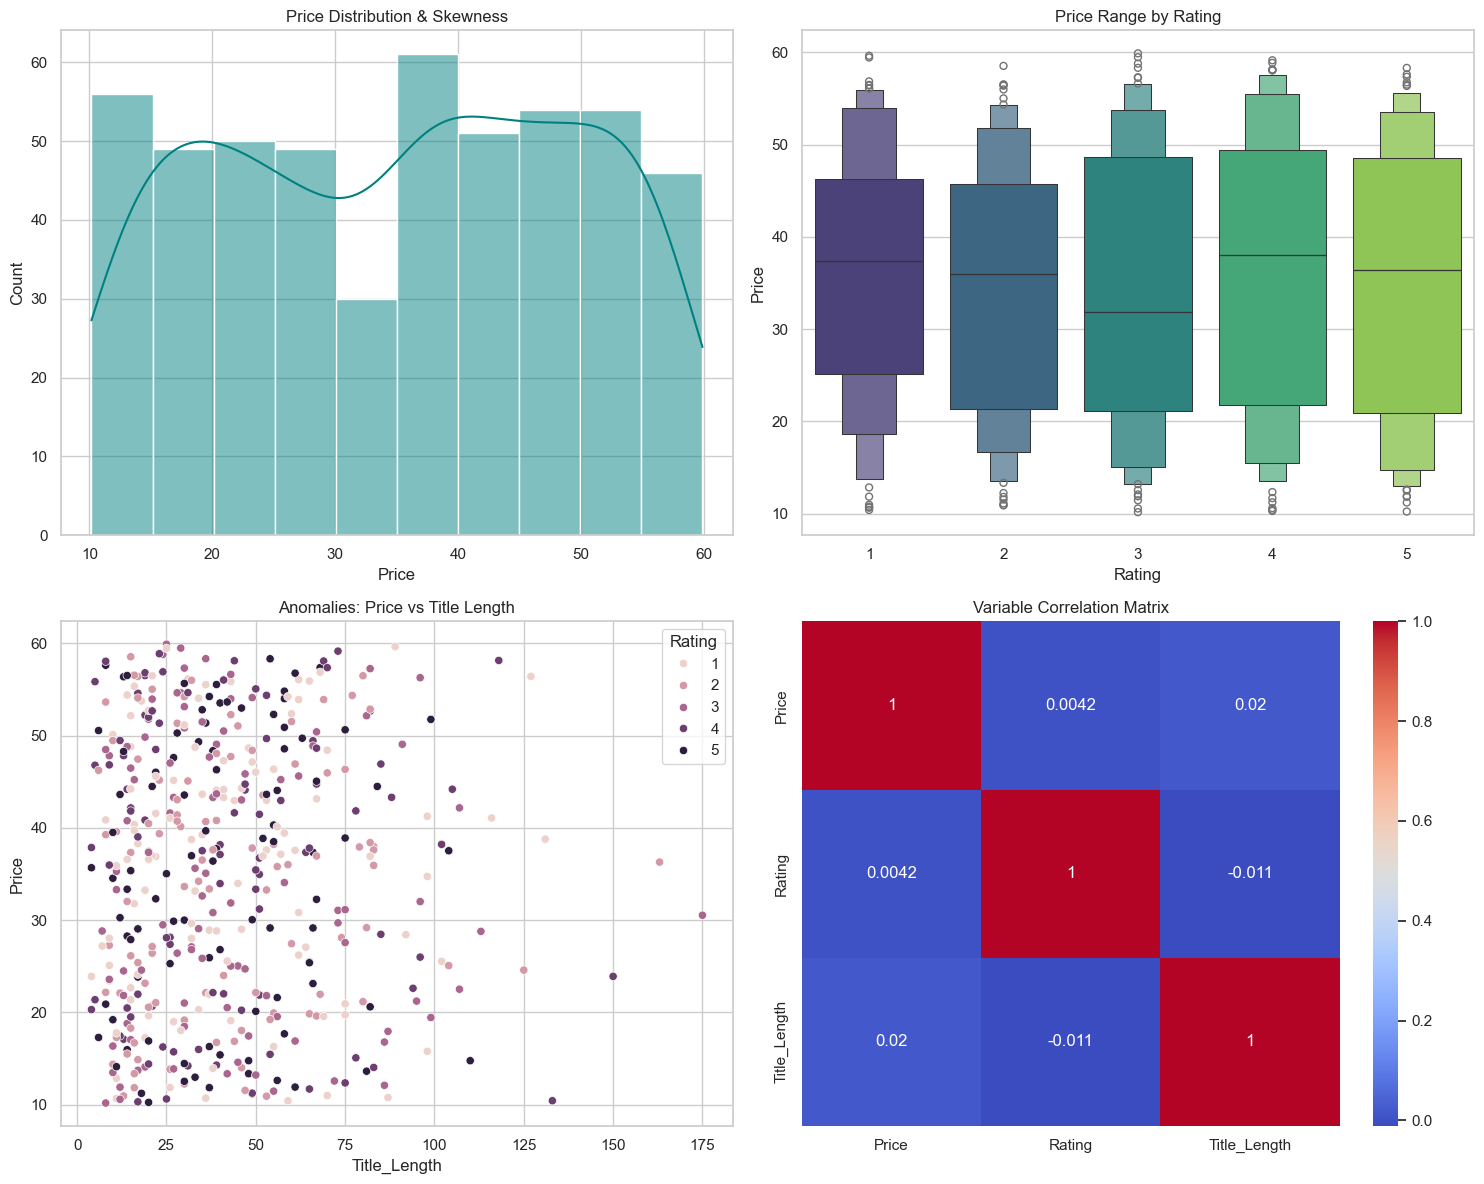


--- Final Insights ---
1. Most expensive book price: £59.9
2. Average book rating: 2.93/5
3. Most frequent rating given: 1


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Initial Setup
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

# 1. DATA LOADING & INITIAL INSPECTION
df = pd.read_csv('books_data_500.csv')

print("--- Data Dimensions ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# 2. ADVANCED DATA CLEANING (Handling Anomalies)
# Cleaning Price: Using Regex to remove non-numeric chars
df['Price'] = df['Price'].replace(r'[^\d.]', '', regex=True).astype(float)

# Cleaning Rating: Professional Mapping
rating_dict = {'One': 1, 'Two': 2, 'Three': 3, 'Four': 4, 'Five': 5}
df['Rating'] = df['Rating'].map(rating_dict)

# Cleaning Availability: Extracting only status
df['Availability'] = df['Availability'].str.strip()

# Check for Duplicates
print(f"Duplicate Rows Found: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)

# 3. FEATURE ENGINEERING
# Title length analyze karna 
df['Title_Length'] = df['Title'].apply(len)

# 4. DESCRIPTIVE STATISTICS & HYPOTHESIS TESTING
print("\n--- Statistical Summary ---")
display(df.describe())

# Hypothesis: "High rated books are more expensive" - Let's test this!
correlation = df['Rating'].corr(df['Price'])
print(f"\nCorrelation between Rating and Price: {correlation:.4f}")

# 5. ADVANCED VISUALIZATIONS (Task 3 Preview)
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# A. Price Distribution (Histogram + KDE)
sns.histplot(df['Price'], kde=True, ax=axes[0,0], color='teal')
axes[0,0].set_title('Price Distribution & Skewness')

# B. Rating vs Price (Boxen Plot - Advanced)
sns.boxenplot(x='Rating', y='Price', data=df, ax=axes[0,1], palette='viridis')
axes[0,1].set_title('Price Range by Rating')

# C. Outlier Detection (Scatter Plot)
sns.scatterplot(x='Title_Length', y='Price', hue='Rating', data=df, ax=axes[1,0])
axes[1,0].set_title('Anomalies: Price vs Title Length')

# D. Correlation Heatmap
sns.heatmap(df[['Price', 'Rating', 'Title_Length']].corr(), annot=True, cmap='coolwarm', ax=axes[1,1])
axes[1,1].set_title('Variable Correlation Matrix')

plt.tight_layout()
plt.show()

# 6. FINAL INSIGHTS (The "Meaningful Questions" Answers)
print("\n--- Final Insights ---")
print(f"1. Most expensive book price: £{df['Price'].max()}")
print(f"2. Average book rating: {df['Rating'].mean():.2f}/5")
print(f"3. Most frequent rating given: {df['Rating'].mode()[0]}")